In [ ]:
# Step 1: Upload ZIP file
from google.colab import files
uploaded = files.upload()


Saving DoorAndWindowDetectionDataset.zip to DoorAndWindowDetectionDataset.zip


In [ ]:
# Step 2: Unzip the uploaded file
import zipfile
import os

# Replace with your actual ZIP filename
zip_filename = "DoorAndWindowDetectionDataset.zip"

# Unzip
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall("dataset")

# Optional: List extracted files
for root, dirs, files in os.walk("dataset"):
    print(root, len(files), "files")


dataset 0 files
dataset/DoorAndWindowDetectionDataset 2 files
dataset/DoorAndWindowDetectionDataset/valid 0 files
dataset/DoorAndWindowDetectionDataset/valid/images 99 files
dataset/DoorAndWindowDetectionDataset/valid/labels 100 files
dataset/DoorAndWindowDetectionDataset/test 0 files
dataset/DoorAndWindowDetectionDataset/test/images 100 files
dataset/DoorAndWindowDetectionDataset/test/labels 100 files
dataset/DoorAndWindowDetectionDataset/train 0 files
dataset/DoorAndWindowDetectionDataset/train/images 527 files
dataset/DoorAndWindowDetectionDataset/train/labels 800 files


In [ ]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 58.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

In [ ]:
# Create the data.yaml file dynamically
data_yaml = """
path: dataset/DoorAndWindowDetectionDataset

train: train/images
val: valid/images
test: test/images

nc: 2
names: ['door', 'window']

"""

with open("data.yaml", "w") as f:
    f.write(data_yaml)


In [ ]:
import os

for root, dirs, files in os.walk("dataset"):
    print(root)


dataset
dataset/DoorAndWindowDetectionDataset
dataset/DoorAndWindowDetectionDataset/valid
dataset/DoorAndWindowDetectionDataset/valid/images
dataset/DoorAndWindowDetectionDataset/valid/labels
dataset/DoorAndWindowDetectionDataset/test
dataset/DoorAndWindowDetectionDataset/test/images
dataset/DoorAndWindowDetectionDataset/test/labels
dataset/DoorAndWindowDetectionDataset/train
dataset/DoorAndWindowDetectionDataset/train/images
dataset/DoorAndWindowDetectionDataset/train/labels


In [ ]:
from ultralytics import YOLO

# Load YOLOv8 model (you can also use 'yolov8m' or 'yolov8l')
model = YOLO("yolov8n.pt")  # 'n' = nano, fast and light for starters

# Train the model
model.train(data="data.yaml", epochs=20, imgsz=640, batch=16)


Ultralytics 8.3.151 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=Fal

train: Scanning /content/dataset/DoorAndWindowDetectionDataset/train/labels.cache... 527 images, 0 backgrounds, 0 corrupt: 100%|██████████| 527/527 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 285.6±44.9 MB/s, size: 29.6 KB)


val: Scanning /content/dataset/DoorAndWindowDetectionDataset/valid/labels.cache... 99 images, 0 backgrounds, 0 corrupt: 100%|██████████| 99/99 [00:00<?, ?it/s]


...

                   all         99       1229      0.802       0.68      0.773      0.566



20 epochs completed in 0.058 hours.
Optimizer stripped from runs/detect/train2/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train2/weights/best.pt, 6.2MB

Validating runs/detect/train2/weights/best.pt...
Ultralytics 8.3.151 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:02<00:00,  1.36it/s]


                   all         99       1229      0.801       0.68      0.772      0.567
                  door         74        143      0.734      0.502      0.628      0.447
                window         99       1086      0.869      0.858      0.917      0.686
Speed: 0.3ms preprocess, 3.7ms inference, 0.0ms loss, 6.1ms postprocess per image
Results saved to runs/detect/train2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a58890e2a90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
!yolo val model=/content/runs/detect/train/weights/best.pt data=data.yaml


Ultralytics 8.3.151 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1124.4±259.2 MB/s, size: 23.0 KB)
val: Scanning /content/dataset/DoorAndWindowDetectionDataset/valid/labels.cache... 99 images, 0 backgrounds, 0 corrupt: 100% 99/99 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 7/7 [00:04<00:00,  1.46it/s]
                   all         99       1229      0.873      0.734      0.801      0.595
                  door         74        143      0.837      0.608      0.691       0.49
                window         99       1086      0.909      0.859      0.911      0.699
Speed: 5.1ms preprocess, 9.2ms inference, 0.0ms loss, 5.7ms postprocess per image
Results saved to runs/detect/val2
💡 Learn more at https://docs.ultralytics.com/modes/val


Saving house1.webp to house1 (1).webp

✅ Uploaded image: house1 (1).webp

image 1/1 /content/house1 (1).webp: 640x480 3 doors, 2 windows, 10.7ms
Speed: 4.0ms preprocess, 10.7ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 480)


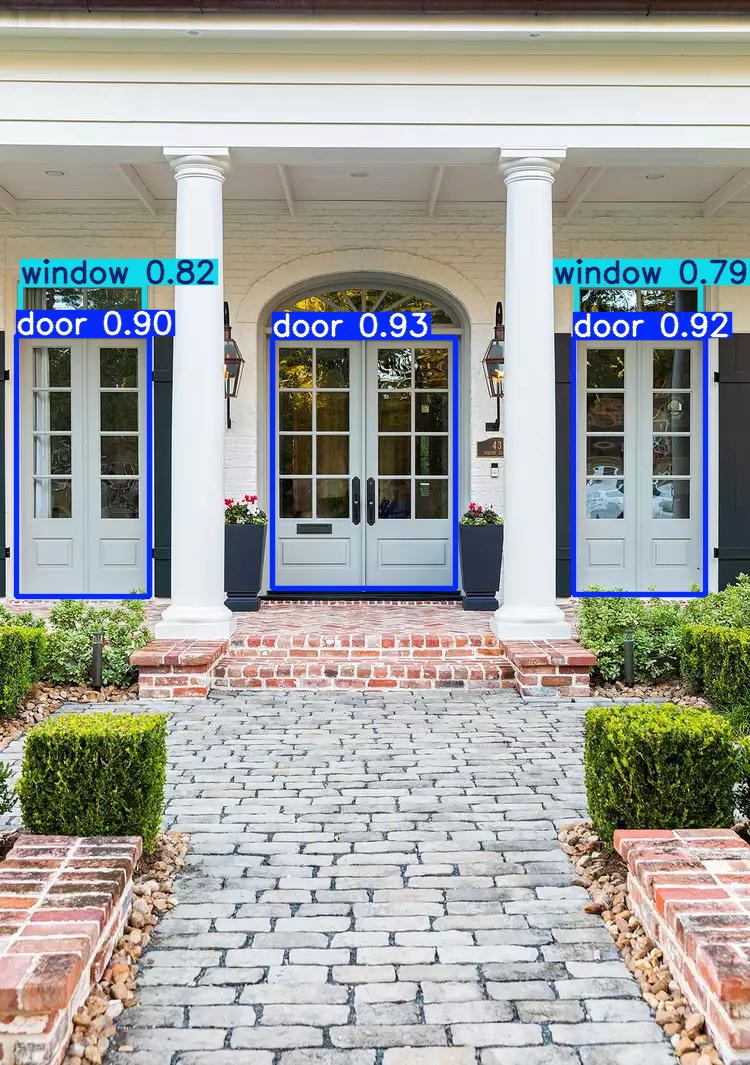

❌ No prediction folder found. Possibly no detections.

📏 Bounding Box Dimensions:
🔹 door - Width: 183.57px, Height: 250.41px
🔹 door - Width: 132.39px, Height: 257.29px
🔹 door - Width: 132.5px, Height: 260.66px
🔹 window - Width: 124.07px, Height: 40.24px
🔹 window - Width: 124.13px, Height: 43.89px

📊 Summary:
door: 3
window: 2


In [ ]:
from google.colab import files
from ultralytics import YOLO
from IPython.display import Image, display
import os
import glob
from collections import Counter

# Step 1: Upload image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
print(f"\n✅ Uploaded image: {img_path}")

# Step 2: Load the trained model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# Step 3: Run prediction
results = model(img_path)

# Step 4: Show the detections (if any)
results[0].show()

# Step 5: Save results
results[0].save()

# Step 6: Find the latest prediction folder
predict_folders = sorted(glob.glob("runs/detect/predict*"))
if not predict_folders:
    print("❌ No prediction folder found. Possibly no detections.")
else:
    latest_folder = predict_folders[-1]
    predicted_img_path = os.path.join(latest_folder, os.path.basename(img_path))

    if os.path.exists(predicted_img_path):
        print(f"✅ Detected image saved at: {predicted_img_path}")
        display(Image(filename=predicted_img_path))
    else:
        print("⚠️ Detection image not found. Possibly no objects were detected.")

# Step 7: Count instances and print bounding box dimensions
print("\n📏 Bounding Box Dimensions:")
names = model.names  # class name mapping
class_ids = results[0].boxes.cls.tolist()
boxes = results[0].boxes.xyxy.tolist()  # xyxy = [x1, y1, x2, y2]

counts = Counter(class_ids)

for i, class_id in enumerate(class_ids):
    label = names[int(class_id)]
    x1, y1, x2, y2 = boxes[i]
    width = round(x2 - x1, 2)
    height = round(y2 - y1, 2)
    print(f"🔹 {label} - Width: {width}px, Height: {height}px")

print("\n📊 Summary:")
for class_id, count in counts.items():
    print(f"{names[int(class_id)]}: {count}")


Saving house2.jpg to house2 (1).jpg

✅ Uploaded image: house2 (1).jpg

image 1/1 /content/house2 (1).jpg: 288x640 1 door, 3 windows, 11.6ms
Speed: 3.1ms preprocess, 11.6ms inference, 1.9ms postprocess per image at shape (1, 3, 288, 640)


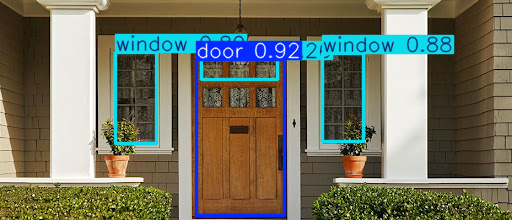

❌ No prediction folder found. Possibly no detections.

📏 Bounding Box Dimensions:
🔹 door - Width: 87.55px, Height: 156.31px
🔹 window - Width: 41.74px, Height: 88.85px
🔹 window - Width: 41.23px, Height: 90.92px
🔹 window - Width: 75.24px, Height: 20.6px

📊 Summary:
door: 1
window: 3


In [ ]:
from google.colab import files
from ultralytics import YOLO
from IPython.display import Image, display
import os
import glob
from collections import Counter

# Step 1: Upload image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
print(f"\n✅ Uploaded image: {img_path}")

# Step 2: Load the trained model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# Step 3: Run prediction
results = model(img_path)

# Step 4: Show the detections (if any)
results[0].show()

# Step 5: Save results
results[0].save()

# Step 6: Find the latest prediction folder
predict_folders = sorted(glob.glob("runs/detect/predict*"))
if not predict_folders:
    print("❌ No prediction folder found. Possibly no detections.")
else:
    latest_folder = predict_folders[-1]
    predicted_img_path = os.path.join(latest_folder, os.path.basename(img_path))

    if os.path.exists(predicted_img_path):
        print(f"✅ Detected image saved at: {predicted_img_path}")
        display(Image(filename=predicted_img_path))
    else:
        print("⚠️ Detection image not found. Possibly no objects were detected.")

# Step 7: Count instances and print bounding box dimensions
print("\n📏 Bounding Box Dimensions:")
names = model.names  # class name mapping
class_ids = results[0].boxes.cls.tolist()
boxes = results[0].boxes.xyxy.tolist()  # xyxy = [x1, y1, x2, y2]

counts = Counter(class_ids)

for i, class_id in enumerate(class_ids):
    label = names[int(class_id)]
    x1, y1, x2, y2 = boxes[i]
    width = round(x2 - x1, 2)
    height = round(y2 - y1, 2)
    print(f"🔹 {label} - Width: {width}px, Height: {height}px")

print("\n📊 Summary:")
for class_id, count in counts.items():
    print(f"{names[int(class_id)]}: {count}")


📤 Please upload the house image...


Saving 1.jpg to 1 (5).jpg
🏠 House image received: 1 (5).jpg

image 1/1 /content/1 (5).jpg: 480x640 4 doors, 3 windows, 8.3ms
Speed: 3.1ms preprocess, 8.3ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)

🔎 Detected: 4 doors, 3 windows

📥 Please upload image for window 1


Saving window1.jpg to window1.jpg

📥 Please upload image for window 2


Saving window1.jpg to window1 (1).jpg

📥 Please upload image for window 3


Saving window1.jpg to window1 (2).jpg

📥 Please upload image for door 1


Saving door1.jpg to door1 (2).jpg

📥 Please upload image for door 2


Saving door1.jpg to door1 (3).jpg

📥 Please upload image for door 3


Saving door1.jpg to door1 (4).jpg

📥 Please upload image for door 4


Saving door1.jpg to door1 (5).jpg

✅ Final image with all replacements:


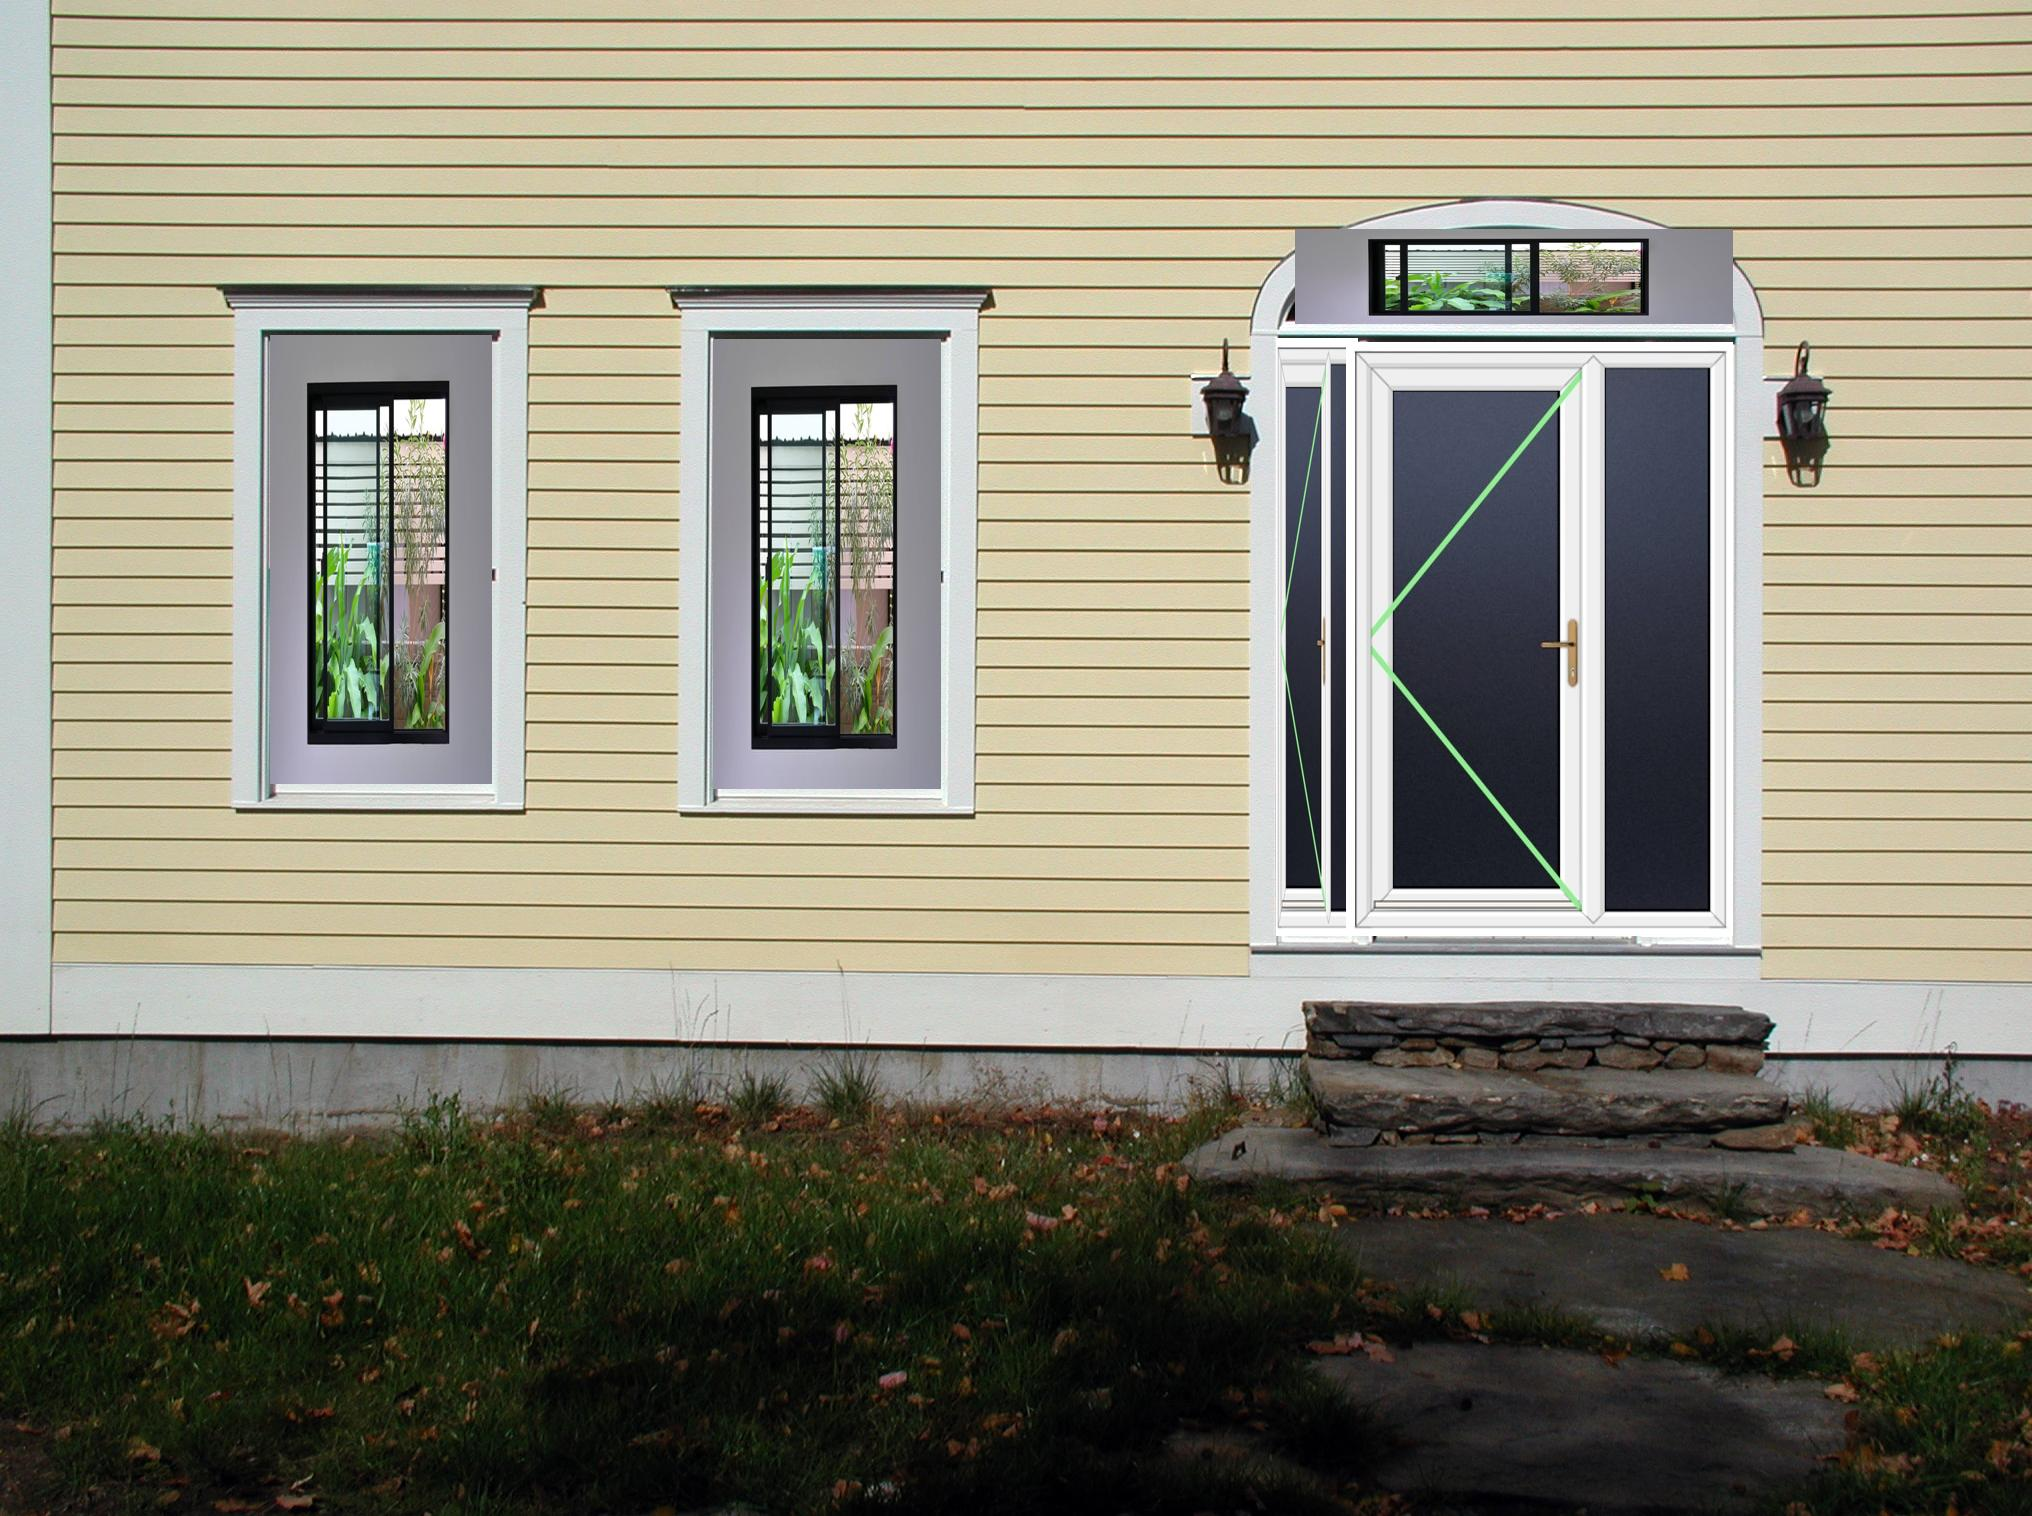

In [ ]:
from ultralytics import YOLO
from PIL import Image as PILImage
import cv2
import os
import numpy as np
from google.colab import files
from IPython.display import display, Image as IPImage
import io

# Step 1: Upload house image
print("📤 Please upload the house image...")
house_upload = files.upload()
house_img_path = list(house_upload.keys())[0]
print(f"🏠 House image received: {house_img_path}")

# Step 2: Load model and detect
model = YOLO('/content/runs/detect/train3/weights/best.pt')
results = model(house_img_path)
boxes = results[0].boxes.xyxy.tolist()
class_ids = results[0].boxes.cls.tolist()
names = model.names

# Step 3: Count doors and windows
label_map = {'door': [], 'window': []}
for i, class_id in enumerate(class_ids):
    label = names[int(class_id)]
    if label in label_map:
        label_map[label].append(i)

print(f"\n🔎 Detected: {len(label_map['door'])} doors, {len(label_map['window'])} windows")

# Step 4: Ask for replacement images one-by-one
replacement_imgs = {'door': [], 'window': []}

def ask_for_replacements(label, count):
    for i in range(count):
        print(f"\n📥 Please upload image for {label} {i + 1}")
        upload = files.upload()
        path = list(upload.keys())[0]
        replacement_imgs[label].append(path)

ask_for_replacements('window', len(label_map['window']))
ask_for_replacements('door', len(label_map['door']))

# Step 5: Replace and generate final image
image_pil = PILImage.open(house_img_path).convert("RGB")

for label in ['window', 'door']:
    for idx, box_idx in enumerate(label_map[label]):
        x1, y1, x2, y2 = map(int, boxes[box_idx])
        w, h = x2 - x1, y2 - y1
        replacement_path = replacement_imgs[label][idx]
        replacement = PILImage.open(replacement_path).resize((w, h))
        image_pil.paste(replacement, (x1, y1))

# Step 6: Display result
buf = io.BytesIO()
image_pil.save(buf, format='JPEG')
buf.seek(0)
print("\n✅ Final image with all replacements:")
display(IPImage(data=buf.getvalue()))


In [ ]:
from ultralytics import YOLO
from PIL import Image as PILImage, ImageDraw
import cv2
import os
import numpy as np
from google.colab import files
from IPython.display import display, Image as IPImage
import io

# Step 1: Upload house image
print("📤 Please upload the house image...")
house_upload = files.upload()
house_img_path = list(house_upload.keys())[0]
print(f"🏠 House image received: {house_img_path}")

# Step 2: Load model and detect
model = YOLO('/content/runs/detect/train3/weights/best.pt')
results = model(house_img_path)
boxes = results[0].boxes.xyxy.tolist()
class_ids = results[0].boxes.cls.tolist()
names = model.names

# Step 3: Organize detected objects
label_map = {'door': [], 'window': []}
for i, class_id in enumerate(class_ids):
    label = names[int(class_id)]
    if label in label_map:
        label_map[label].append((i, label))

print(f"\n🔎 Detected: {len(label_map['door'])} doors, {len(label_map['window'])} windows")

# Step 4: Replace each one with visual highlight
image_pil = PILImage.open(house_img_path).convert("RGB")

for label in ['window', 'door']:
    for idx, (box_idx, _) in enumerate(label_map[label]):
        temp_image = image_pil.copy()
        draw = ImageDraw.Draw(temp_image)
        x1, y1, x2, y2 = map(int, boxes[box_idx])

        # Draw rectangle around current item
        draw.rectangle([x1, y1, x2, y2], outline="red", width=4)
        draw.text((x1, y1 - 10), f"{label.capitalize()} {idx+1}", fill="red")

        # Display current item to replace
        buf = io.BytesIO()
        temp_image.save(buf, format='JPEG')
        buf.seek(0)
        print(f"\n📌 Replace this {label} {idx+1}:")
        display(IPImage(data=buf.getvalue()))

        # Ask for replacement image
        print(f"📥 Please upload replacement image for {label} {idx + 1}")
        upload = files.upload()
        replacement_path = list(upload.keys())[0]

        # Paste resized replacement image
        replacement = PILImage.open(replacement_path).resize((x2 - x1, y2 - y1))
        image_pil.paste(replacement, (x1, y1))

# Step 5: Display final image
buf = io.BytesIO()
image_pil.save(buf, format='JPEG')
buf.seek(0)
print("\n✅ Final image with all replacements done:")
display(IPImage(data=buf.getvalue()))
